# Libraries

In [4]:
import pandas as pd
import boto3
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Check from Assignment

In [3]:



hour_df = pd.read_parquet("s3://dsan6000-wikipedia/hourly_parquet/20260901_040000.parquet")
hour_df.head()

,datetime,$schema,meta,id,type,namespace,title,title_url,comment,timestamp,...,wiki,parsedcomment,log_id,log_type,log_action,log_params,log_action_comment,patrolled,file_ts,file_ts_str
0,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Jake_O%...,2.063884e+09,edit,0,Jake O'Donnell,https://en.wikipedia.org/wiki/Jake_O%27Donnell,Fix dash,1788235202,...,enwiki,Fix dash,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
1,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Beverid...,2.063884e+09,edit,0,Beveridge Award,https://en.wikipedia.org/wiki/Beveridge_Award,Add source,1788235202,...,enwiki,Add source,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
2,2026-09-01 04:00:01,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1920_Un...,2.063884e+09,edit,0,1920 United States presidential election in Wa...,https://en.wikipedia.org/wiki/1920_United_Stat...,/* Counties that flipped from Democratic to Re...,1788235201,...,enwiki,"<span class=""autocomment""><a href=""/wiki/1920_...",NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
3,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1987_Ae...,2.063884e+09,edit,0,1987 Aegean crisis,https://en.wikipedia.org/wiki/1987_Aegean_crisis,added a bit of context,1788235202,...,enwiki,added a bit of context,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
4,2026-09-01 04:00:03,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Marvin_...,2.063884e+09,edit,0,Marvin Schwäbe,https://en.wikipedia.org/wiki/Marvin_Schw%C3%A4be,NaN,1788235203,...,enwiki,NaN,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000


# Set Up

In [5]:
s3 = boto3.client("s3")

bucket = "dsan6000-jg2292"
prefix = "wikipedia-hourly/"

images_dir = Path("images")
images_dir.mkdir(exist_ok=True)

# Find and load the Parquet files from S3

In [6]:
response = s3.list_objects_v2(
    Bucket=bucket,
    Prefix=prefix
)

hourly_data = []

for item in response.get("Contents", []):
    key = item["Key"]

    if key.endswith(".parquet"):
        hour_df = pd.read_parquet(f"s3://{bucket}/{key}")
        hourly_data.append(hour_df)

df = pd.concat(hourly_data, ignore_index=True)

df.head()

,datetime,$schema,meta,id,type,namespace,title,title_url,comment,timestamp,...,wiki,parsedcomment,log_id,log_type,log_action,log_params,log_action_comment,patrolled,file_ts,file_ts_str
0,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Jake_O%...,2.063884e+09,edit,0,Jake O'Donnell,https://en.wikipedia.org/wiki/Jake_O%27Donnell,Fix dash,1788235202,...,enwiki,Fix dash,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
1,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Beverid...,2.063884e+09,edit,0,Beveridge Award,https://en.wikipedia.org/wiki/Beveridge_Award,Add source,1788235202,...,enwiki,Add source,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
2,2026-09-01 04:00:01,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1920_Un...,2.063884e+09,edit,0,1920 United States presidential election in Wa...,https://en.wikipedia.org/wiki/1920_United_Stat...,/* Counties that flipped from Democratic to Re...,1788235201,...,enwiki,"<span class=""autocomment""><a href=""/wiki/1920_...",NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
3,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1987_Ae...,2.063884e+09,edit,0,1987 Aegean crisis,https://en.wikipedia.org/wiki/1987_Aegean_crisis,added a bit of context,1788235202,...,enwiki,added a bit of context,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
4,2026-09-01 04:00:03,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Marvin_...,2.063884e+09,edit,0,Marvin Schwäbe,https://en.wikipedia.org/wiki/Marvin_Schw%C3%A4be,NaN,1788235203,...,enwiki,NaN,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000


# Prepare Hourly Counts

In [8]:
df["datetime"] = pd.to_datetime(df["datetime"])

hourly_counts = (
    df.groupby("datetime")
      .size()
      .reset_index(name="event_count")
)

hourly_type_counts = (
    df.groupby(["datetime", "type"])
      .size()
      .reset_index(name="event_count")
)

hourly_counts.head()

,datetime,event_count
0,2026-09-01 04:00:01,4
1,2026-09-01 04:00:02,3
2,2026-09-01 04:00:03,1
3,2026-09-01 04:00:04,1
4,2026-09-01 04:00:05,2


# Total Events Per Hour

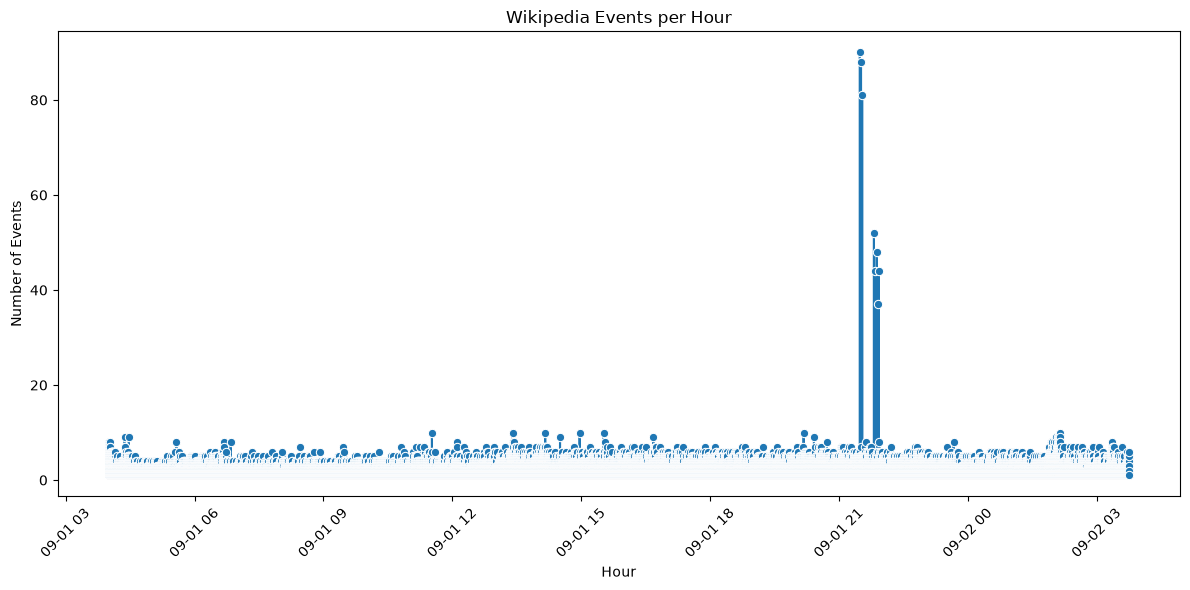

In [9]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=hourly_counts,
    x="datetime",
    y="event_count",
    marker="o"
)

plt.title("Wikipedia Events per Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Events")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(images_dir / "hourly-events.svg")
plt.savefig(images_dir / "hourly-events.png")

plt.show()

# Events By Type

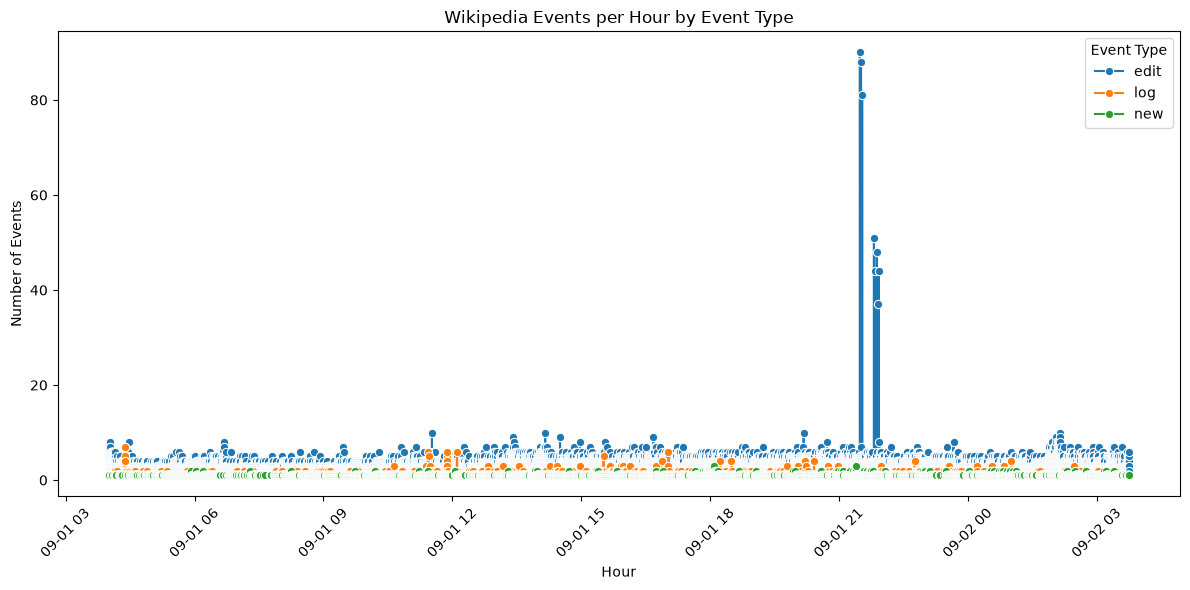

In [10]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=hourly_type_counts,
    x="datetime",
    y="event_count",
    hue="type",
    marker="o"
)

plt.title("Wikipedia Events per Hour by Event Type")
plt.xlabel("Hour")
plt.ylabel("Number of Events")
plt.xticks(rotation=45)
plt.legend(title="Event Type")
plt.tight_layout()

plt.savefig(images_dir / "events-by-type.svg")
plt.savefig(images_dir / "events-by-type.png")

plt.show()